<a href="https://colab.research.google.com/github/andreacangiani/NSPDE-ANA2024/blob/main/Python/CP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Divided differences using sparse matrix

Import the usual modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym

New module: sparse algebra

In [2]:
import scipy.sparse as sp

Function implementing the forward difference in sparse format

In [13]:

def func(N):
    data=[-np.ones(N),np.ones(N)]
    return sp.diags(data,[-1,1],format="csr")

print(func(4))
A=func(4)
print(A.todense())

  (0, 1)	1.0
  (1, 0)	-1.0
  (1, 2)	1.0
  (2, 1)	-1.0
  (2, 3)	1.0
  (3, 2)	-1.0
  (3, 4)	1.0
  (4, 3)	-1.0
[[ 0.  1.  0.  0.  0.]
 [-1.  0.  1.  0.  0.]
 [ 0. -1.  0.  1.  0.]
 [ 0.  0. -1.  0.  1.]
 [ 0.  0.  0. -1.  0.]]


Exmaple of Forward Difference matrix

In [8]:
t = sym.var('t')
fsym=sym.sin(t)
fdsym=fsym.diff(t,1)
f=sym.lambdify(t,fsym)
fd=sym.lambdify(t,fdsym)


In [17]:
a=0
b=np.pi/2
N=100
h=(b-a)/N
A=func(N)/(2*h)
x=np.linspace(a,b,N+1)
u=f(x)
uhD=A.dot(u)
#print(uhD)
print(max(abs(uhD[1:N]-fd(x[1:N]))))

4.111777111193149e-05


Test: use the FD to evaluate the derivative of $f(x)=\frac{x^2}{2}$

In [6]:
import numpy as np
import sympy as sym
# Fix function f using symbolic tool
t = sym.var('t')
fsym = 0.5 * t**2
fdsym=fsym.diff(t,1)
# Define the function as an inline function
f = sym.lambdify(t, fsym )
fd = sym.lambdify(t,fdsym )


def forward_diff(n):
    data=[-np.ones(n+1),np.ones(n)]
    return sp.diags(data,[0,1],format="csr")

# Set up interval and cardinality of the grid

# set up grid points


# Evaluate FD matrix


# Values of the derivative at the grid points


# Print results


Compute max error

In [13]:
a=0
b=1
n=1000
h=1/n
x=np.linspace(a,b,n+1)
A=forward_diff(n)/h
u=f(x)
uhd=A.dot(u)
#print(uhd)
print(max(abs(uhd[0:n]-fd(x[0:n]))))

0.0005000000000854321


Exercise 1. Find a way to evaluate execution time and compare full vs sparse exectution time in function of the grid size N.

Repeat the above exersise and use central divided difference instead of forward divided difference

# Finite Differences for two-points boundary value problems with constant coefficients

Poisson problem in 1D:

$-u''(x)=f(x) \quad \in (a,b)$

$u(a)=0, \quad u(b)=0$

We use the second central divided difference to approxima the second derivative.

Given $h>0$,

$u''(x)≈\frac{u(x+h)-2u(x)+u(x-h)}{h^2}$

Function for second central matrix

In [14]:
def CD2(N):
    data=[np.ones(n),-2*np.ones(n+1),np.ones(n)]
    return sp.diags(data,[-1,0,1],format="csr")
  # Function defining nominator of
  # second central FD formula on a
  # uniform grid in sparse CSR format


Example of second central matrix.

Test problem:

$(a,b)=(0,\pi)$

u(x)=sin(x)

Define FD problem:

for $h=(b-a)/N$

$ A U = - h^2 F $

with $A$ the nominator of CD formula.

In [29]:



# Right-hand side


# Homogeneous Dirichlet boundary conditions



Import solver

In [30]:
from scipy.sparse.linalg import spsolve
uh=spsolve(A,F)


Solve problem and print result

In [ ]:
# Compute solution at internal nodes

# plot solution


0.008265416966228623


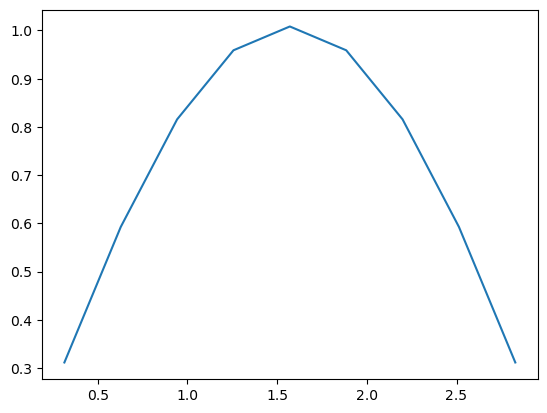

In [34]:
# print max error
import matplotlib.pyplot as plt
print(np.max(np.abs(uh+fd(x[1:-1]))))
plt.plot(x[1:-1],uh)

**Exercise 2.** test for convergence and plot convergence plot

**Exercise 3.** Solve the problem with nonhomogeneous Dirichlet conditions:

$-\alpha u''(x)=f(x) \quad \in (a,b)$

$u(a)=u_a, \quad u(b)=u_b$

For example, you could fix: $(a,b)=(0,\pi/2)$, solution $u$ as before, $\alpha=\frac{1}{2}$

**Exercise 4.** Solve the problem with (homogeneous) Neumann conditions:

$-\alpha u''(x)=f(x) \quad \in (a,b)$

$u(a)=u_a, \quad u'(b)=0$

For example, you could fix: $(a,b)=(0,\pi/2)$, solution $u$ as before, $\alpha=1$.

**Exercise 5.** Solve the reaction-advection-diffusion problem (still with central differences):

$-\alpha u''(x)+\beta u'(x)+\gamma u(x)=f(x) \quad \in (a,b)$

$u(a)=u_a, \quad u(b)=u_b$
